In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
df = pd.read_csv('data/silver/cleaned_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (465, 3)

Columns: ['source', 'text', 'html']

First 3 rows:


,source,text,html
0,cloudflare_Made_in_CA_Grocery_Guide,Brand\n\t\nProducts\n\t\nManufactured In,"<th class=""column-1 dt-orderable-asc dt-ordera..."
1,cloudflare_Made_in_CA_Grocery_Guide,"Bassili's Best\tFrozen chicken lasagna, meat l...","\n\t<td class=""column-1"">Bassili's Best</td><t..."
2,cloudflare_Made_in_CA_Grocery_Guide,"BC Hot House Foods\tFresh produce (tomatoes, p...","\n\t<td class=""column-1"">BC Hot House Foods</t..."


In [4]:
print("=== Data Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicates (based on source+text) ===")
print(df.duplicated(subset=['source','text']).sum())

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   source  465 non-null    str  
 1   text    464 non-null    str  
 2   html    462 non-null    str  
dtypes: str(3)
memory usage: 11.0 KB

=== Missing Values ===
source    0
text      1
html      3
dtype: int64

=== Duplicates (based on source+text) ===
0


Source distribution:
source
cloudflare_Made_in_CA_Grocery_Guide    461
Made_in_CA_Grocery_Guide                 2
pydoll_id                                1
pydoll_result                            1
Name: count, dtype: int64


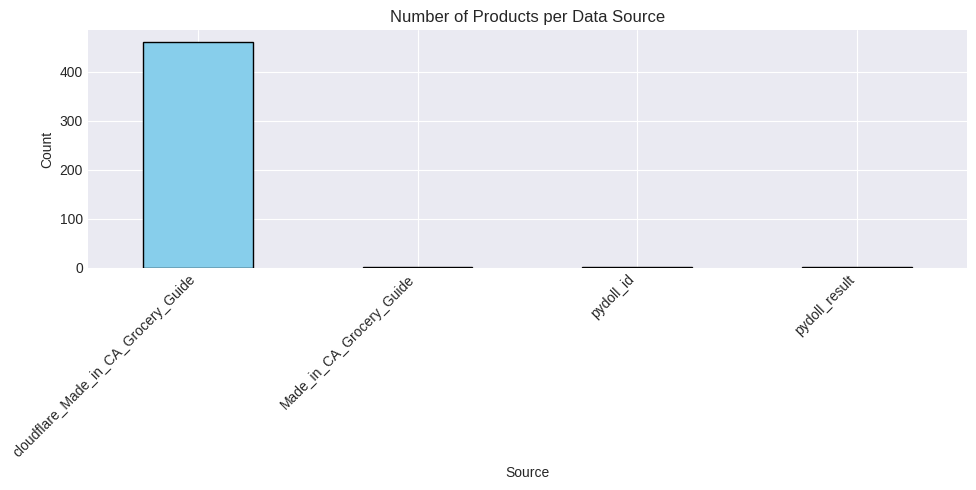

In [5]:
source_counts = df['source'].value_counts()
print("Source distribution:")
print(source_counts)

plt.figure(figsize=(10,5))
source_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Products per Data Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/gold/source_distribution.png')
plt.show()

Top 10 guessed brands:
brand_guess
Greenfield Natural Meat        2
Maple Leaf Foods               2
Sunny Boy Foods                2
Georgian Bay Granola           2
Heartbeat Hot Sauce            2
Brand Products Manufactured    1
Bassili's Best Frozen          1
BC Hot House                   1
Bergen Farms Fresh             1
Cedar Phoenicia Pearl          1
Name: count, dtype: int64


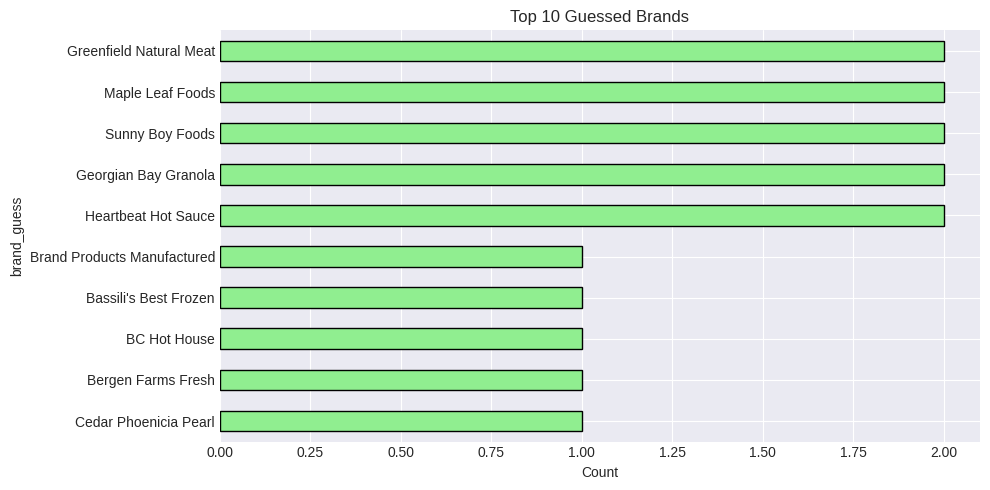

In [7]:
df['text'] = df['text'].fillna('').astype(str)

def extract_brand(text):
    words = text.split()[:3]
    return ' '.join(words)

df['brand_guess'] = df['text'].apply(extract_brand)

top_brands = df['brand_guess'].value_counts().head(10)
print("Top 10 guessed brands:")
print(top_brands)

plt.figure(figsize=(10,5))
top_brands.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Top 10 Guessed Brands')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/gold/top_brands.png')
plt.show()

Text length statistics:
count    465.000000
mean      87.391398
std       51.790043
min        0.000000
25%       59.000000
50%       75.000000
75%      102.000000
max      500.000000
Name: text_length, dtype: float64


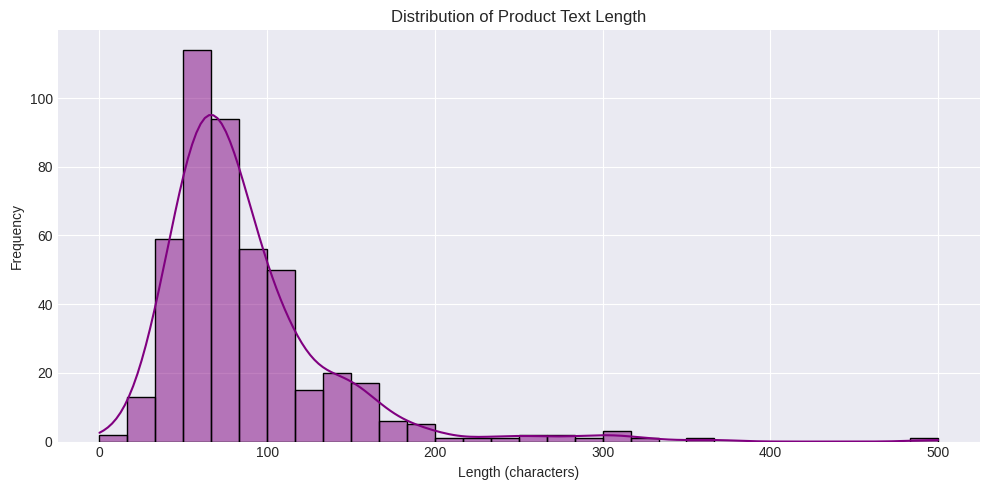

In [8]:
# تحليل طول النصوص (بعد التأكد من أن text نصية)
df['text_length'] = df['text'].apply(len)
print("Text length statistics:")
print(df['text_length'].describe())

plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Product Text Length')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('data/gold/text_length_dist.png')
plt.show()

/tmp/ipykernel_193777/3227753536.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='Category', y='Count', palette='viridis')


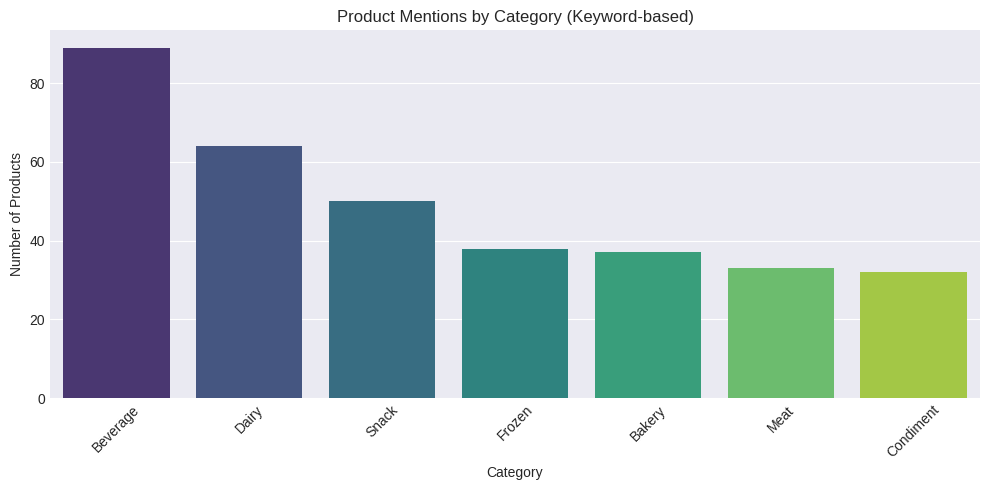

In [9]:
keywords = {
    'Dairy': ['cheese', 'milk', 'yogurt', 'cream', 'butter'],
    'Meat': ['beef', 'chicken', 'pork', 'sausage', 'ham'],
    'Bakery': ['bread', 'bun', 'pastry', 'cookie', 'cake'],
    'Beverage': ['juice', 'soda', 'water', 'tea', 'coffee'],
    'Frozen': ['frozen', 'ice cream', 'pizza'],
    'Snack': ['chips', 'popcorn', 'cracker', 'snack'],
    'Condiment': ['sauce', 'dressing', 'ketchup', 'mustard']
}

category_counts = {}
for cat, words in keywords.items():
    pattern = '|'.join(words)
    mask = df['text'].str.lower().str.contains(pattern, na=False)
    category_counts[cat] = mask.sum()

cat_df = pd.DataFrame(category_counts.items(), columns=['Category', 'Count'])
cat_df = cat_df.sort_values('Count', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=cat_df, x='Category', y='Count', palette='viridis')
plt.title('Product Mentions by Category (Keyword-based)')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/gold/category_mentions.png')
plt.show()

In [10]:
# ملخص نهائي
print("=== Final Summary for CFDB ===")
print(f"Total unique products: {len(df)}")
print(f"Data sources: {df['source'].nunique()}")
print(f"Average text length: {df['text_length'].mean():.1f} chars")
print("\nEDA completed. Visualizations saved in data/gold/")

=== Final Summary for CFDB ===
Total unique products: 465
Data sources: 4
Average text length: 87.4 chars

EDA completed. Visualizations saved in data/gold/
